In [1]:
%load_ext autoreload
%autoreload 2

# 02 — Pilot Disagreement Analysis

Systematic analysis of where the 95 zero-shot models disagree on the 5 pilot DMS assays.

**Assays**: A4_HUMAN_Seuma_2022, ADRB2_HUMAN_Jones_2020, ACE2_HUMAN_Chan_2020,
AMIE_PSEAE_Wrenbeck_2017, A0A192B1T2_9HIV1_Haddox_2018

**Key figure**: pairwise model agreement heatmap (Cohen's κ).

All figures → `results/figures/`, tables → `results/tables/`,
intermediates → `data/processed/`, log → `results/ARTIFACTS_LOG.csv`.

In [2]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.proteingym_loader import load_dms_scores, get_model_columns
from src.analysis.disagreement import (
    binarize_scores,
    pairwise_agreement,
    variant_disagreement_score,
    score_spread,
)
from src.viz.heatmaps import plot_score_heatmap, plot_pairwise_agreement
from src.utils.persistence import save_figure, save_table, save_processed

NB = "02_pilot_disagreement"

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120

## 1  Load data

In [3]:
PILOTS = [
    "A4_HUMAN_Seuma_2022",
    "ADRB2_HUMAN_Jones_2020",
    "ACE2_HUMAN_Chan_2020",
    "AMIE_PSEAE_Wrenbeck_2017",
    "A0A192B1T2_9HIV1_Haddox_2018",
]

df = load_dms_scores("../data/raw", dms_ids=PILOTS)
models = get_model_columns(df, exclude=("DMS_score_bin",))
print(f"{len(models)} models, {len(df):,} variants across {df['dms_id'].nunique()} assays")

Loading assays:   0%|          | 0/5 [00:00<?, ?assay/s]

Loading assays:  20%|██        | 1/5 [00:00<00:01,  3.30assay/s]

Loading assays:  40%|████      | 2/5 [00:00<00:00,  3.01assay/s]

Loading assays:  80%|████████  | 4/5 [00:00<00:00,  5.18assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  5.89assay/s]

Loading assays: 100%|██████████| 5/5 [00:00<00:00,  5.03assay/s]


Proteins (UniProt IDs) : 5
DMS assays             : 5
Zero-shot models       : 95
Total variant rows     : 43,638
Models found           : ['Site_Independent', 'EVmutation', 'DeepSequence_single', 'DeepSequence_ensemble', 'EVE_single', 'EVE_ensemble']...

95 models, 43,638 variants across 5 assays


## 2  Binarize scores (per-assay-per-model median split)

In [4]:
df_b = binarize_scores(df, models)

binary_cols = [f"{m}_binary" for m in models]
frac_ones = df_b[binary_cols].mean().describe()
print("Fraction of 1s per model (should be ~0.5):")
print(frac_ones.round(3))

Fraction of 1s per model (should be ~0.5):
count     95.0
mean       0.5
std        0.0
min      0.498
25%        0.5
50%        0.5
75%        0.5
max        0.5
dtype: Float64


## 3  Pairwise model agreement — THE key figure

Cohen's κ for every model pair across all 5 assays combined.  
Models that agree cluster together (Ward linkage on 1−κ distance).

In [5]:
kappa = pairwise_agreement(df_b, models)
print(f"Kappa matrix: {kappa.shape}")
off_diag = kappa.values[~np.eye(len(models), dtype=bool)]
print(f"Mean off-diagonal kappa: {np.nanmean(off_diag):.3f}")

Pairwise kappa:   0%|          | 0/4465 [00:00<?, ?pair/s]

Pairwise kappa:   1%|          | 28/4465 [00:00<00:15, 278.54pair/s]

Pairwise kappa:   1%|▏         | 62/4465 [00:00<00:14, 311.41pair/s]

Pairwise kappa:   2%|▏         | 96/4465 [00:00<00:13, 323.53pair/s]

Pairwise kappa:   3%|▎         | 130/4465 [00:00<00:13, 329.21pair/s]

...

Pairwise kappa:  98%|█████████▊| 4392/4465 [00:13<00:00, 323.46pair/s]

Pairwise kappa:  99%|█████████▉| 4427/4465 [00:13<00:00, 328.98pair/s]

Pairwise kappa: 100%|█████████▉| 4462/4465 [00:13<00:00, 333.67pair/s]

Pairwise kappa: 100%|██████████| 4465/4465 [00:13<00:00, 326.65pair/s]

Kappa matrix: (95, 95)
Mean off-diagonal kappa: 0.449


  [saved figure] results/figures/pairwise_agreement_clustermap.png


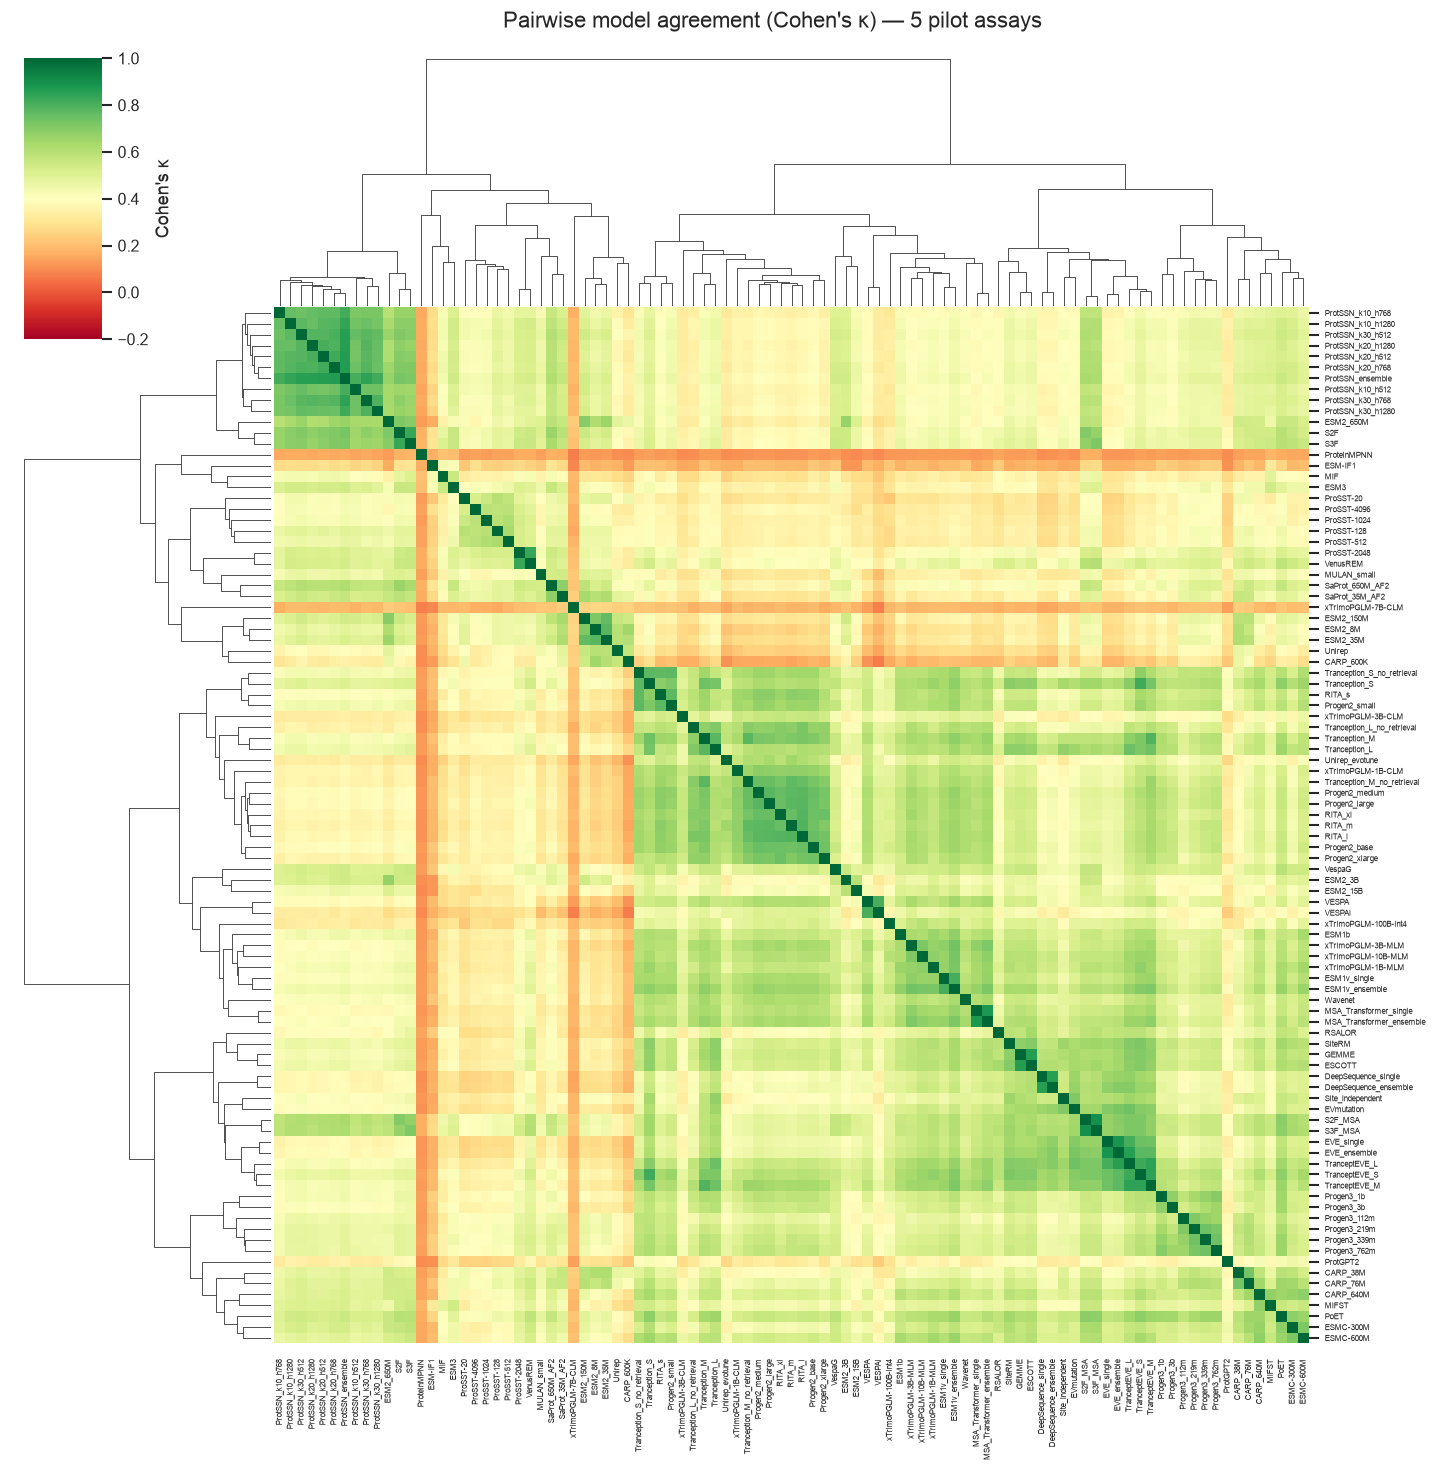

In [6]:
g = plot_pairwise_agreement(
    kappa, figsize=(13, 13),
    title="Pairwise model agreement (Cohen's κ) — 5 pilot assays"
)
save_figure(
    g, "pairwise_agreement_clustermap", notebook=NB,
    description="95×95 Cohen's κ clustermap with Ward-linkage clustering; models that agree group together",
)
plt.show()

### Top-10 most- and least-agreeing pairs + save full matrix

In [7]:
kappa_pairs = (
    kappa.where(np.triu(np.ones(kappa.shape), k=1).astype(bool))
         .stack()
         .rename("kappa")
         .reset_index()
         .rename(columns={"level_0": "model_a", "level_1": "model_b"})
         .dropna()
         .sort_values("kappa", ascending=False)
         .reset_index(drop=True)
)
print("Most agreeing pairs:"); print(kappa_pairs.head(10).to_string(index=False))
print(); print("Least agreeing pairs:"); print(kappa_pairs.tail(10).to_string(index=False))

save_table(
    kappa, "pairwise_kappa_matrix", notebook=NB,
    description="Full 95×95 Cohen's κ matrix of pairwise model agreement across 5 pilot assays",
)
save_table(
    kappa_pairs.head(10), "most_agreeing_pairs_top10", notebook=NB,
    description="Top-10 model pairs with highest pairwise Cohen's κ",
)
save_table(
    kappa_pairs.tail(10), "least_agreeing_pairs_top10", notebook=NB,
    description="Top-10 model pairs with lowest pairwise Cohen's κ (most disagreement)",
)

Most agreeing pairs:
               model_a                  model_b    kappa
               S2F_MSA                  S3F_MSA 0.899170
            EVE_single             EVE_ensemble 0.885558
MSA_Transformer_single MSA_Transformer_ensemble 0.873505
      ProtSSN_k20_h768         ProtSSN_ensemble 0.867638
      ProtSSN_k20_h512         ProtSSN_ensemble 0.863238
                 GEMME                   ESCOTT 0.862551
          EVE_ensemble            TranceptEVE_L 0.858380
      ProtSSN_k30_h512         ProtSSN_ensemble 0.856822
   DeepSequence_single    DeepSequence_ensemble 0.856593
     ProtSSN_k20_h1280         ProtSSN_ensemble 0.855447

Least agreeing pairs:
       model_a           model_b    kappa
   ProteinMPNN xTrimoPGLM-3B-CLM 0.098492
Unirep_evotune       ProteinMPNN 0.097850
      ProtGPT2       ProteinMPNN 0.095696
     CARP_600K       ProteinMPNN 0.095467
      ESM2_15B       ProteinMPNN 0.095192
        VESPAl       ProteinMPNN 0.091938
       ESM-IF1 xTrimoPGLM-7B-CLM 0.

PosixPath('/Users/naodaraya/variant-disagreement-atlas/notebooks/../results/tables/least_agreeing_pairs_top10.csv')

## 4  Per-variant disagreement scores

In [8]:
df_b["disagreement_score"] = variant_disagreement_score(df_b, models)
df_b["score_spread"]       = score_spread(df, models)

stats_df = df_b.groupby("dms_id")[["disagreement_score", "score_spread"]].describe().round(3)
print(stats_df)
save_table(
    stats_df, "per_pilot_disagreement_stats", notebook=NB,
    description="Descriptive statistics of disagreement entropy and score spread per pilot assay",
)

                             disagreement_score                            \
                                          count   mean    std  min    25%   
dms_id                                                                      
A0A192B1T2_9HIV1_Haddox_2018            12577.0  0.671  0.276  0.0  0.452   
A4_HUMAN_Seuma_2022                     14811.0  0.617  0.317  0.0  0.340   
ACE2_HUMAN_Chan_2020                     2223.0  0.627  0.287  0.0  0.380   
ADRB2_HUMAN_Jones_2020                   7800.0  0.448  0.324  0.0  0.147   
AMIE_PSEAE_Wrenbeck_2017                 6227.0  0.641  0.311  0.0  0.380   

                                                score_spread                \
                                50%    75%  max        count   mean    std   
dms_id                                                                       
A0A192B1T2_9HIV1_Haddox_2018  0.742  0.922  1.0      12577.0  0.687  0.238   
A4_HUMAN_Seuma_2022           0.700  0.922  1.0      14811.0  0.576  0.

PosixPath('/Users/naodaraya/variant-disagreement-atlas/notebooks/../results/tables/per_pilot_disagreement_stats.csv')

### Save key intermediates

In [9]:
meta_cols   = ["protein_id", "dms_id", "mutant", "experimental_fitness",
               "disagreement_score", "score_spread"]
binary_save = meta_cols + binary_cols

save_processed(
    df_b[binary_save], "pilot_binarized_scores", notebook=NB,
    description="Binarized model predictions (per-assay-per-model median split) for 5 pilot assays",
)
save_processed(
    df_b[meta_cols].copy(), "pilot_variant_disagreement_scores", notebook=NB,
    description="Per-variant disagreement entropy and score spread for 5 pilot assays",
)

  [saved processed] data/processed/pilot_binarized_scores.parquet
  [saved processed] data/processed/pilot_variant_disagreement_scores.parquet


PosixPath('/Users/naodaraya/variant-disagreement-atlas/notebooks/../data/processed/pilot_variant_disagreement_scores.parquet')

## 5  Disagreement distributions per assay

  [saved figure] results/figures/disagreement_distribution_pilots.png


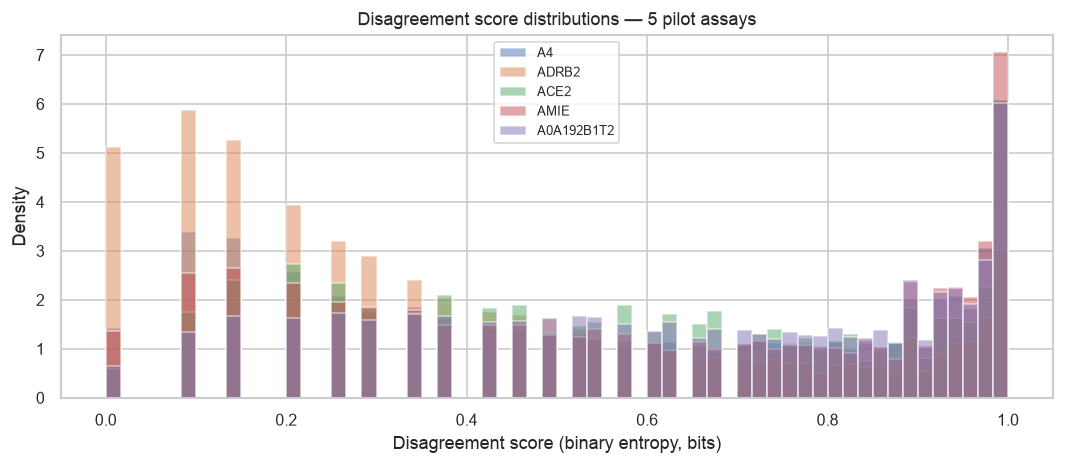

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for pid in PILOTS:
    sub = df_b[df_b["dms_id"] == pid]["disagreement_score"].dropna()
    ax.hist(sub, bins=60, alpha=0.5, density=True, label=pid.split("_")[0])
ax.set_xlabel("Disagreement score (binary entropy, bits)")
ax.set_ylabel("Density")
ax.set_title("Disagreement score distributions — 5 pilot assays")
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(
    fig, "disagreement_distribution_pilots", notebook=NB,
    description="Overlaid density histograms of per-variant disagreement entropy for 5 pilot assays",
)
plt.show()

## 6  Per-pilot score heatmaps (sorted by disagreement)

Top 50 most-disagreed variants per assay. Z-scored continuous scores.  
Red = high predicted fitness, blue = low.

  [saved figure] results/figures/score_heatmap_A4_HUMAN.png


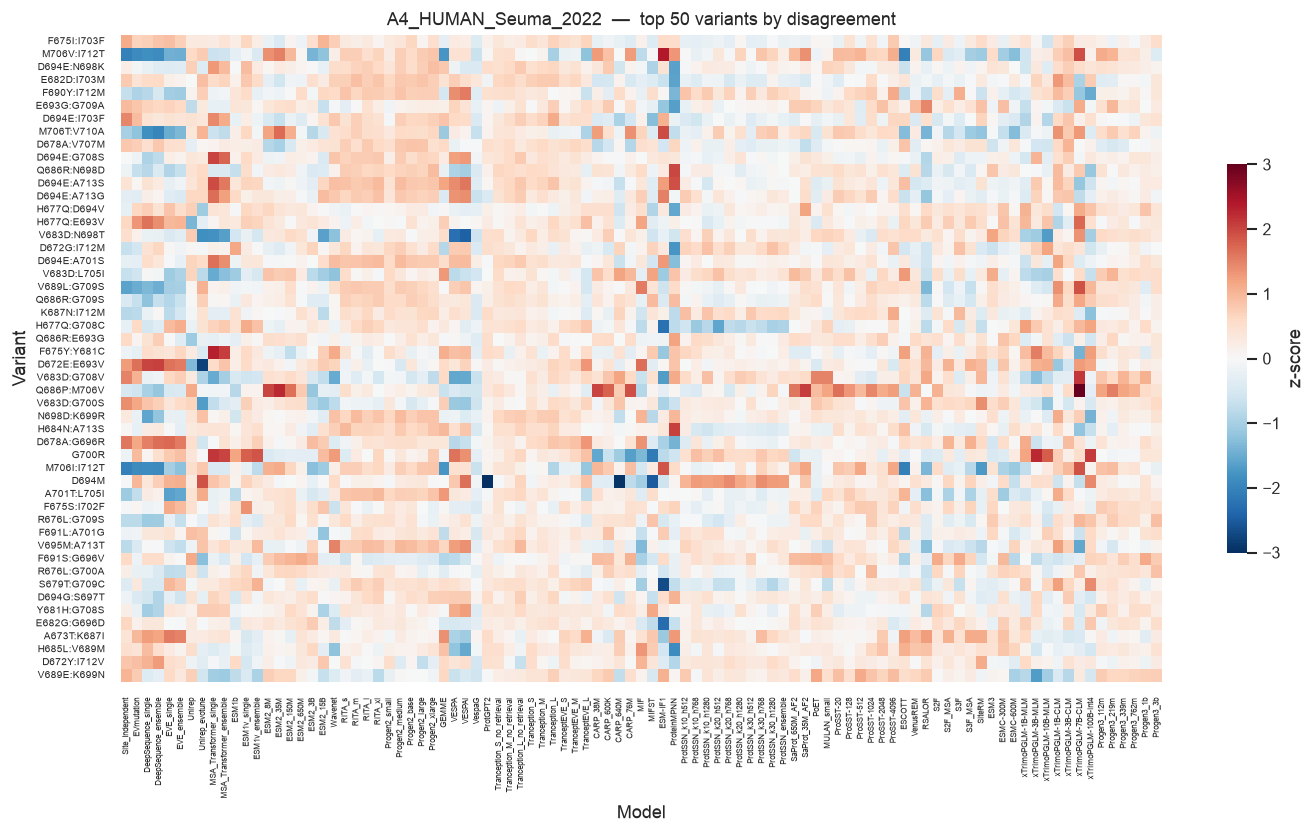

  [saved figure] results/figures/score_heatmap_ADRB2_HUMAN.png


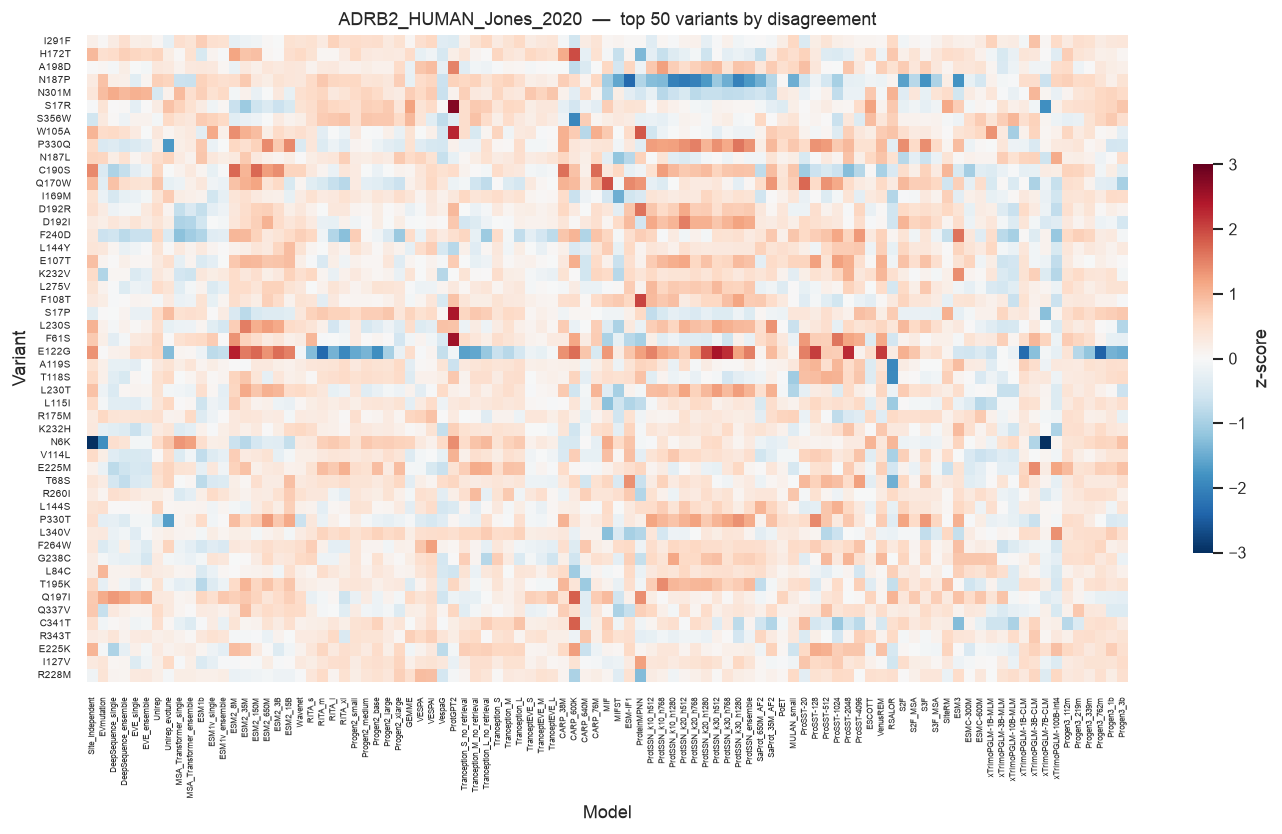

  [saved figure] results/figures/score_heatmap_ACE2_HUMAN.png


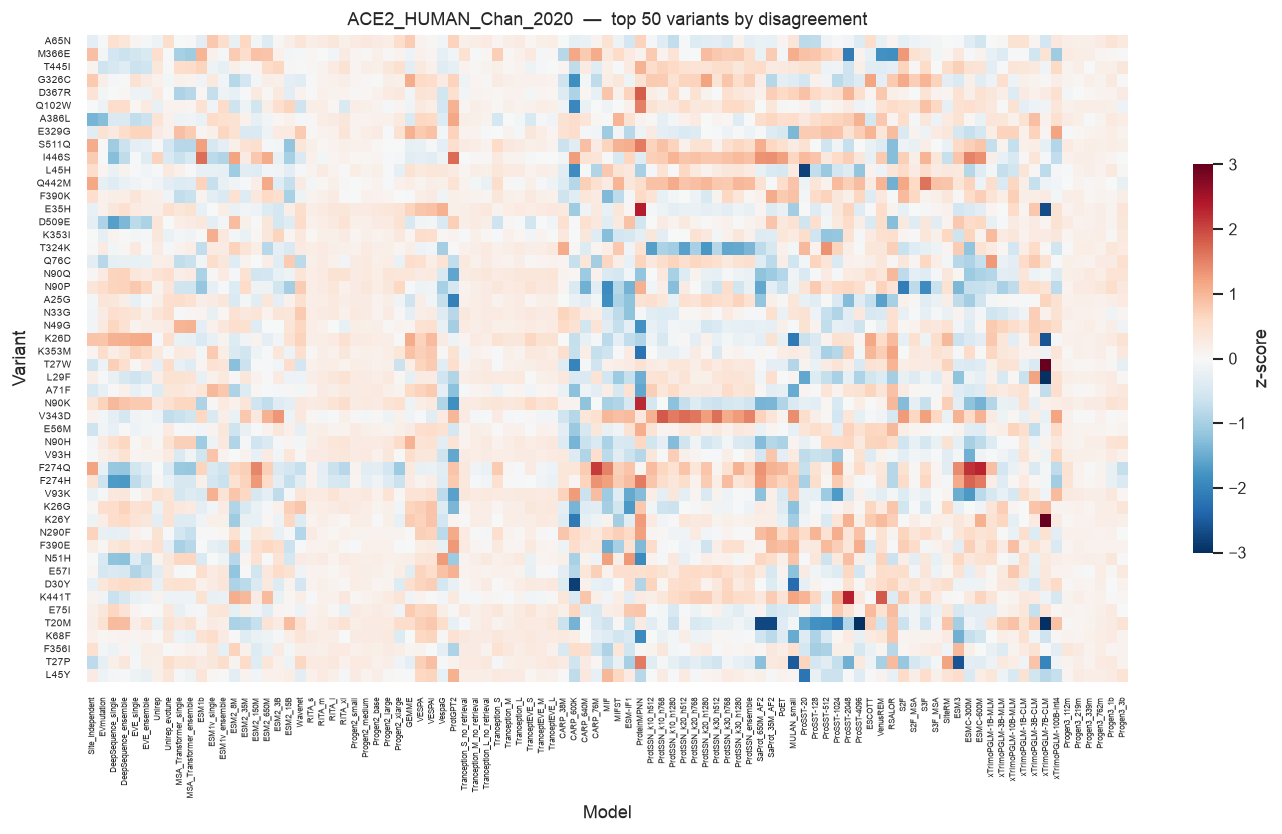

  [saved figure] results/figures/score_heatmap_AMIE_PSEAE.png


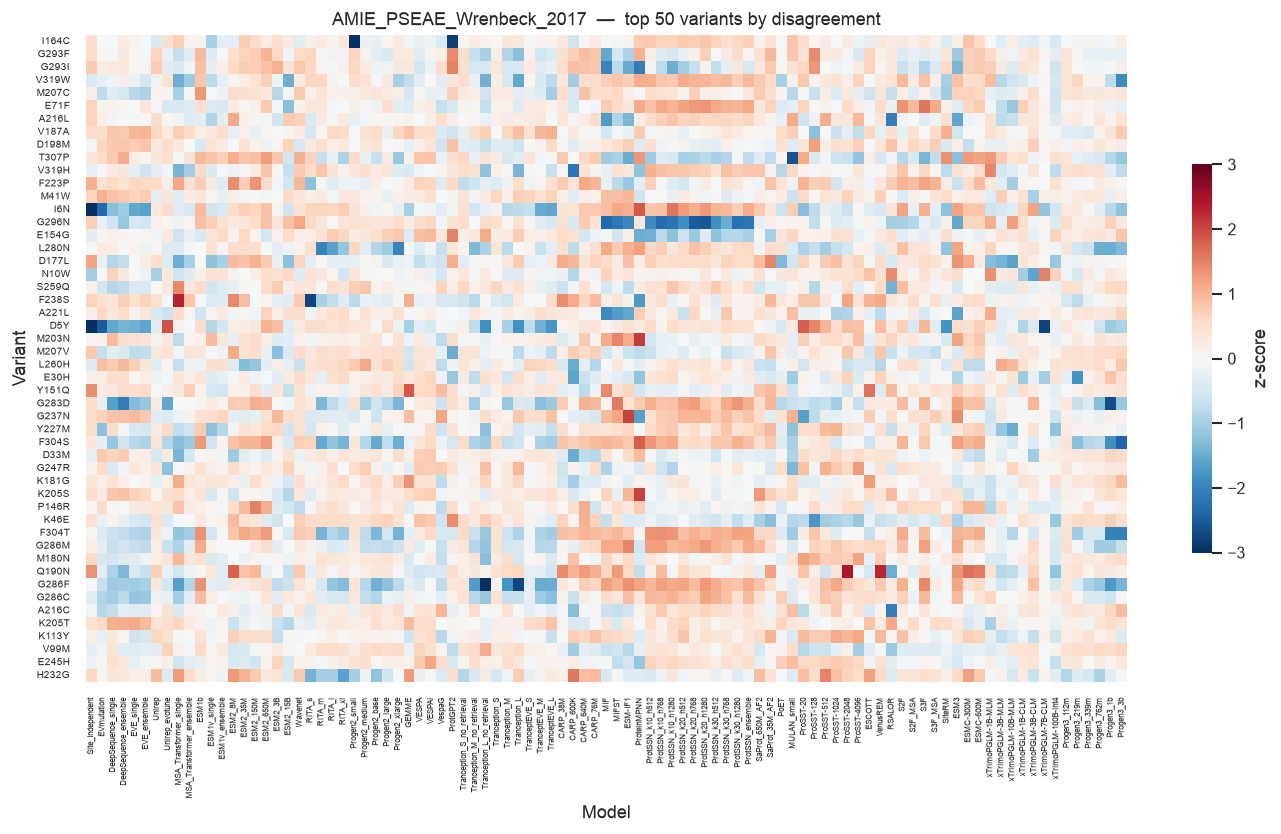

  [saved figure] results/figures/score_heatmap_A0A192B1T2_HIV1.png


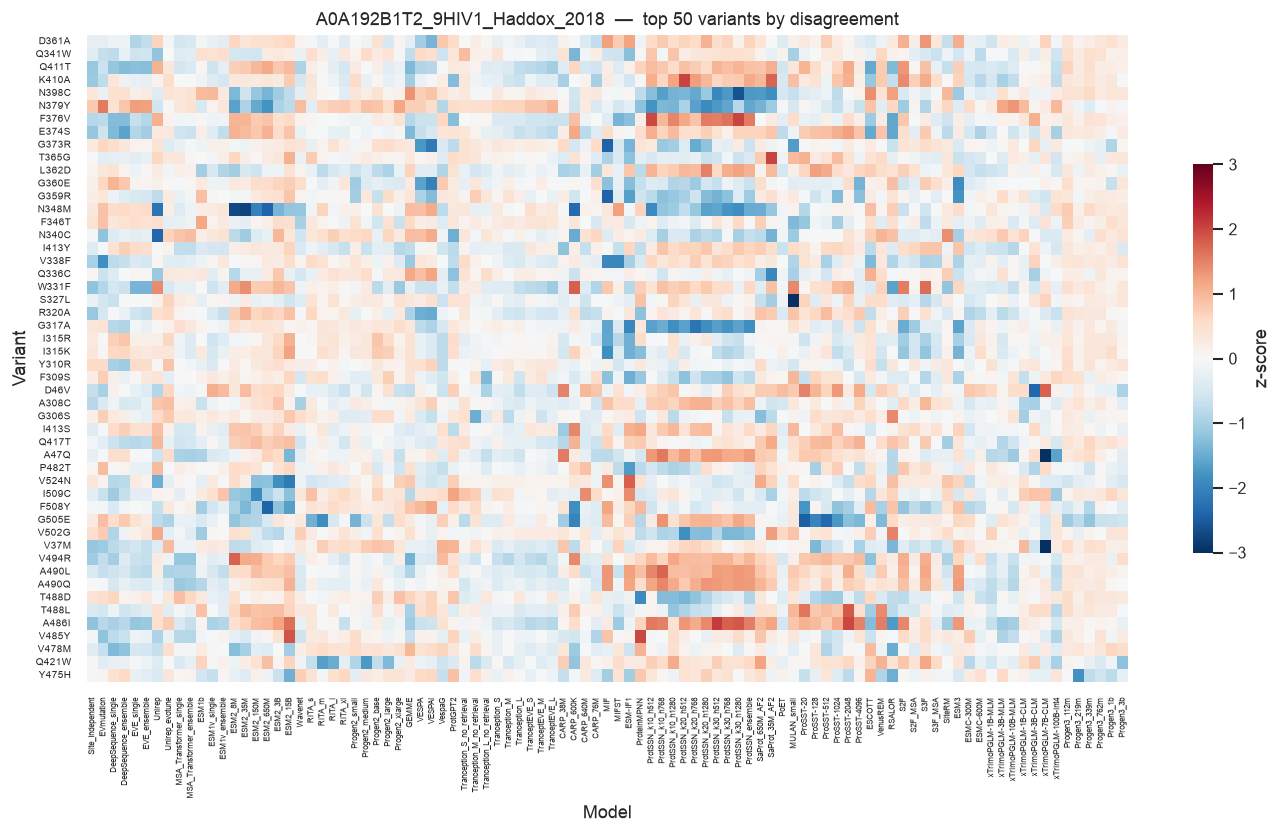

In [11]:
ASSAY_SHORT = {
    "A4_HUMAN_Seuma_2022":           "A4_HUMAN",
    "ADRB2_HUMAN_Jones_2020":        "ADRB2_HUMAN",
    "ACE2_HUMAN_Chan_2020":          "ACE2_HUMAN",
    "AMIE_PSEAE_Wrenbeck_2017":      "AMIE_PSEAE",
    "A0A192B1T2_9HIV1_Haddox_2018": "A0A192B1T2_HIV1",
}

for pid in PILOTS:
    fig = plot_score_heatmap(
        df, dms_id=pid, models=models,
        sort_by_disagreement=True, n_variants=50, figsize=(14, 7)
    )
    short = ASSAY_SHORT[pid]
    save_figure(
        fig, f"score_heatmap_{short}", notebook=NB,
        description=f"Top-50 most-disagreed variants, z-scored model scores heatmap for {pid}",
    )
    plt.show()

## 7  Top-30 most-disagreed variants across all pilots

In [12]:
KEY_MODELS = [
    "ESM1b", "ESM2_650M", "EVE_single", "Tranception_L",
    "ProteinMPNN", "SaProt_650M_AF2", "GEMME",
]
KEY_MODELS = [m for m in KEY_MODELS if m in df.columns]

top30 = (
    df_b.sort_values("disagreement_score", ascending=False)
        .head(30)
        [["dms_id", "mutant", "experimental_fitness",
          "disagreement_score", "score_spread"] + KEY_MODELS]
        .reset_index(drop=True)
)
top30.index += 1
print(top30.round(3).to_string())

save_table(
    top30, "top_30_disagreement_variants", notebook=NB,
    description="Top-30 most-disagreed-upon variants with experimental fitness and key model scores",
)

                          dms_id       mutant  experimental_fitness  disagreement_score  score_spread   ESM1b  ESM2_650M  EVE_single  Tranception_L  ProteinMPNN  SaProt_650M_AF2   GEMME
1   A0A192B1T2_9HIV1_Haddox_2018         Q81G                -0.725                 1.0         0.669  -8.021      0.279     -19.494         -0.013       -1.988           -2.802 -10.547
2   A0A192B1T2_9HIV1_Haddox_2018        F508Y                -2.848                 1.0         0.676 -14.905     -5.475     -16.558         -0.011       -1.985           -2.933  -2.447
3   A0A192B1T2_9HIV1_Haddox_2018        F688T                 0.184                 1.0         0.446 -11.134     -0.927     -18.449         -0.012       -1.990           -0.348  -8.338
4            A4_HUMAN_Seuma_2022  F690S:N698D                -4.813                 1.0         0.699 -29.625     -0.653      -9.672         -0.018       -2.212           -0.018  -5.308
5           ACE2_HUMAN_Chan_2020        T445I                -0.374   

PosixPath('/Users/naodaraya/variant-disagreement-atlas/notebooks/../results/tables/top_30_disagreement_variants.csv')

## 8  Scatter: experimental fitness vs. disagreement score

**Hypothesis**: models agree on extreme variants (clearly lethal or clearly beneficial)
and disagree most on middle-fitness variants where the ground truth is ambiguous.

Expected shape: an inverted-U (high disagreement at intermediate fitness).

  [saved figure] results/figures/fitness_vs_disagreement_pilots.png


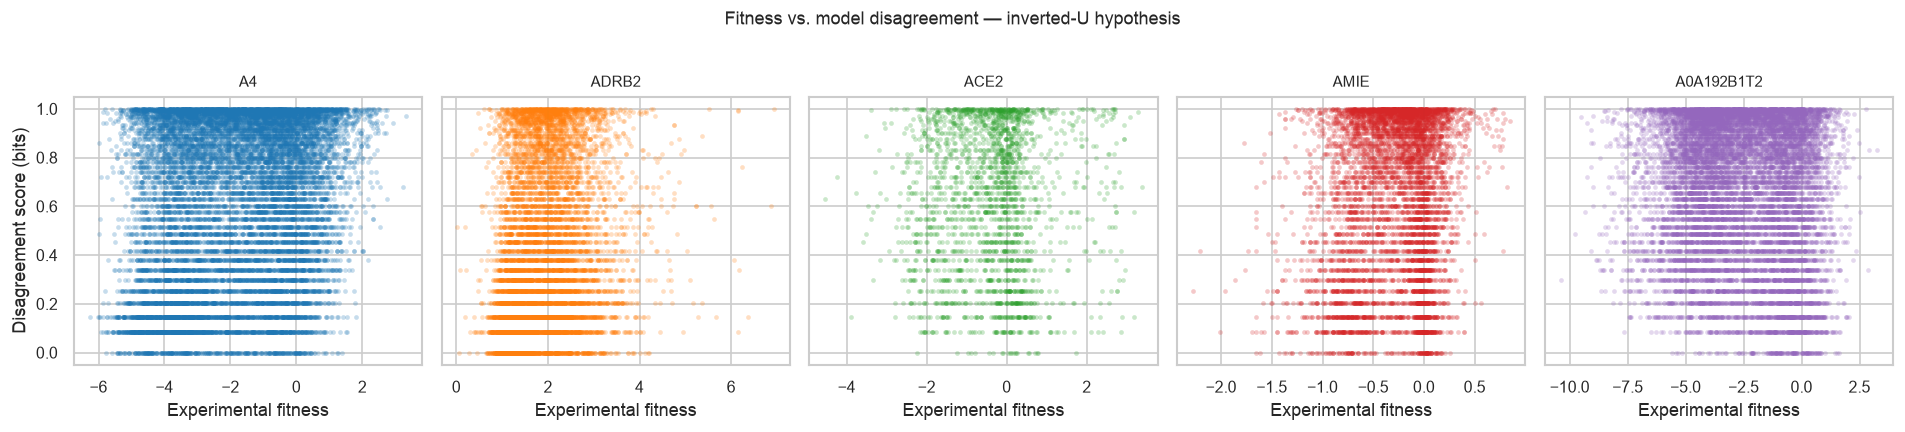

In [13]:
fig, axes = plt.subplots(1, len(PILOTS), figsize=(16, 3.5), sharey=True)
palette = sns.color_palette("tab10", len(PILOTS))

for ax, pid, color in zip(axes, PILOTS, palette):
    sub = df_b[df_b["dms_id"] == pid].dropna(
        subset=["experimental_fitness", "disagreement_score"]
    )
    ax.scatter(
        sub["experimental_fitness"], sub["disagreement_score"],
        alpha=0.25, s=8, color=color, linewidths=0,
    )
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        smooth = lowess(
            sub["disagreement_score"].values,
            sub["experimental_fitness"].values,
            frac=0.3, return_sorted=True,
        )
        ax.plot(smooth[:, 0], smooth[:, 1], color="black", linewidth=1.5)
    except ImportError:
        pass
    ax.set_title(pid.split("_")[0], fontsize=9)
    ax.set_xlabel("Experimental fitness")

axes[0].set_ylabel("Disagreement score (bits)")
fig.suptitle("Fitness vs. model disagreement — inverted-U hypothesis", y=1.02, fontsize=11)
plt.tight_layout()
save_figure(
    fig, "fitness_vs_disagreement_pilots", notebook=NB,
    description="5-panel scatter of experimental fitness vs. disagreement entropy with LOWESS smoother",
)
plt.show()

### Spearman ρ: |fitness| vs. disagreement (testing agreement on extremes)

In [14]:
from scipy import stats

rows = []
for pid in PILOTS:
    sub = df_b[df_b["dms_id"] == pid].dropna(
        subset=["experimental_fitness", "disagreement_score"]
    )
    fit = sub["experimental_fitness"]
    fit_norm = (fit - fit.mean()) / fit.std()
    r, p = stats.spearmanr(fit_norm.abs(), sub["disagreement_score"])
    rows.append({"assay": pid, "spearman_r": round(r, 3), "p_value": f"{p:.2e}"})

corr_df = pd.DataFrame(rows)
print(corr_df.to_string(index=False))
print()
print("Negative r → higher |fitness| = lower disagreement (models agree on extremes).")

save_table(
    corr_df, "fitness_vs_disagreement_spearman", notebook=NB,
    description="Spearman ρ between |experimental fitness| and disagreement entropy per pilot assay",
)

                       assay  spearman_r  p_value
         A4_HUMAN_Seuma_2022      -0.054 3.53e-11
      ADRB2_HUMAN_Jones_2020      -0.144 1.85e-37
        ACE2_HUMAN_Chan_2020      -0.077 2.58e-04
    AMIE_PSEAE_Wrenbeck_2017      -0.216 1.48e-66
A0A192B1T2_9HIV1_Haddox_2018      -0.088 5.18e-23

Negative r → higher |fitness| = lower disagreement (models agree on extremes).
  [saved table]  results/tables/fitness_vs_disagreement_spearman.csv


PosixPath('/Users/naodaraya/variant-disagreement-atlas/notebooks/../results/tables/fitness_vs_disagreement_spearman.csv')